In [1]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import spacy

spacy.prefer_gpu()
nlp = spacy.load("en_core_web_lg")

In [2]:
# loading the data
data = pd.read_csv("dataset/mtsamples.csv")
data = data.dropna(subset=["transcription"])
data

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."
...,...,...,...,...,...,...
4994,4994,Patient having severe sinusitis about two to ...,Allergy / Immunology,Chronic Sinusitis,"HISTORY:, I had the pleasure of meeting and e...",NaN
4995,4995,This is a 14-month-old baby boy Caucasian who...,Allergy / Immunology,Kawasaki Disease - Discharge Summary,"ADMITTING DIAGNOSIS: , Kawasaki disease.,DISCH...","allergy / immunology, mucous membranes, conjun..."
4996,4996,A female for a complete physical and follow u...,Allergy / Immunology,Followup on Asthma,"SUBJECTIVE: , This is a 42-year-old white fema...",NaN
4997,4997,Mother states he has been wheezing and coughing.,Allergy / Immunology,Asthma in a 5-year-old,"CHIEF COMPLAINT: , This 5-year-old male presen...",NaN


In [3]:
# --- EXTENDED DATA PURIFICATION: FIXING ALL GROUND TRUTH CROSSTALK ---
print(f"Initial Dataset Size: {len(data)}")

# Locate mislabeled Orthopedic entries that are actually Neurology (Spine Surgeries)
ortho_mask = data['medical_specialty'].str.strip() == 'Orthopedic'
neuro_keywords = ['nerve', 'brain', 'spine', 'spinal', 'laminectomy', 'disc', 'cord', 'neuropathy', 'radiculopathy', 'cervical', 'lumbar', 'epidural']
neuro_pattern = '|'.join(neuro_keywords)
is_neuro_leaning = data['keywords'].fillna('').str.lower().str.contains(neuro_pattern) | \
                   data['description'].fillna('').str.lower().str.contains(neuro_pattern)

bad_ortho_neuro_idx = data[ortho_mask & is_neuro_leaning].index
print(f"Dropping {len(bad_ortho_neuro_idx)} neurological/spine cases masquerading as Orthopedic.")

data = data.drop(bad_ortho_neuro_idx).reset_index(drop=True)
print(f"Purified Dataset Size: {len(data)}")


Initial Dataset Size: 4966
Dropping 134 neurological/spine cases masquerading as Orthopedic.
Purified Dataset Size: 4832


In [4]:
# PRE PROCessing

ABBREVIATIONS = {
    "pt": "patient",
    "hx": "history",
    "dx": "diagnosis",
    "tx": "treatment",
    "sx": "symptoms",
    "htn": "hypertension",
    "cp": "chest pain",
    "sob": "shortness of breath"
}

def extract_headers(text):
    # extract from raw (uppercase) text before any lowercasing
    headers = re.findall(r'\b([A-Z][A-Z\s]{3,}):', text)
    return " ".join(h.strip().replace(" ", "_") for h in headers)

def expand_abbreviations(text, abbr_dict):
    for abbr, full in abbr_dict.items():
        pattern = r'\b' + re.escape(abbr) + r'\b'
        # append expansion alongside original token — never discard original
        text = re.sub(pattern, lambda m: m.group() + " " + full, text)
    return text

def clean_symbols(text):
    text = re.sub(r'[^a-zA-Z0-9\s.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def preprocess(text):
    # used for the spacy NLP pass only (entity/negation extraction)
    text = text.lower()
    text = expand_abbreviations(text, ABBREVIATIONS)
    text = clean_symbols(text)
    return text

In [5]:
GENERIC_TERMS = {
    "patient", "history", "exam", "examination", "procedure",
    "doctor", "report", "mg", "day", "right", "left", "time",
    "date", "pain", "incision", "anesthesia", "blood", "pressure",
    "status", "room", "hospital", "discharge"
}

def extract_entities(doc):
    entities = []
    for chunk in doc.noun_chunks:
        phrase = chunk.text.lower().strip()
        if phrase in GENERIC_TERMS:
            continue
        if chunk.root.pos_ == "NOUN":
            entities.append({
                "entity": phrase,
                "root": chunk.root,
                "status": "present"
            })
    return entities


In [6]:
NEGATION_CUES = {
    "no", "not", "denies", "without", "negative", "clear", "absent", "resolved", "free"
}

def detect_negation(entities):
    for entity in entities:
        root = entity["root"]
        # check ancestor verbs
        for ancestor in root.ancestors:
            if ancestor.lemma_.lower() in NEGATION_CUES:
                entity["status"] = "negated"
        # check children
        for child in root.children:
            if child.dep_ == "neg" or child.lemma_.lower() in NEGATION_CUES:
                entity["status"] = "negated"
        # robust window checking (3 tokens before)
        for tok in root.doc[max(0, root.i - 3):root.i]:
            if tok.lemma_.lower() in NEGATION_CUES:
                entity["status"] = "negated"
    return entities


In [7]:
def process_document(text):
    if not isinstance(text, str):
        return ""
    headers = extract_headers(text)      # extract from raw before lowercasing
    cleaned = preprocess(text)
    doc = nlp(cleaned)

    entities = extract_entities(doc)
    entities = detect_negation(entities)

    entity_list = [e["entity"] for e in entities]
    negated_list = [e["entity"] for e in entities if e["status"] == "negated"]

    return cleaned, entity_list, negated_list, headers

In [8]:
# data filter: target specific specialties to improve accuracy and avoid generic overlaps
target_specialties = [' Gastroenterology', ' Cardiovascular / Pulmonary', ' Orthopedic', ' Neurology']
data = data[data['medical_specialty'].isin(target_specialties)]

print("Remaining rows:", len(data))


Remaining rows: 1039


In [9]:
# --- ADDED FOR DATA BALANCING ---
# 1. Find the size of the smallest class
min_class_size = data['medical_specialty'].value_counts().min()

# 2. Undersample all classes to explicitly match the minority class
data = data.groupby('medical_specialty').sample(n=int(min_class_size), random_state=42).reset_index(drop=True)

print("Balanced Data Distribution:")
print(data['medical_specialty'].value_counts())
print("Total Samples:", len(data))


Balanced Data Distribution:
medical_specialty
Cardiovascular / Pulmonary    221
Gastroenterology              221
Neurology                     221
Orthopedic                    221
Name: count, dtype: int64
Total Samples: 884


In [10]:
data[["clean_text", "entities", "negated_entities", "headers"]] = data["transcription"].apply(process_document).apply(pd.Series)

In [11]:
SPECIALTY_WORDS = {
    'colonoscopy', 'endoscopy', 'polyps', 'bowel', 'gastric', 'abdomen', 'esophagus', 'stomach', 'ulcer',
    'coronary', 'artery', 'aortic', 'ventricular', 'atrial', 'valve', 'myocardial', 'stenosis',
    'fracture', 'joint', 'femur', 'tendon', 'bone', 'knee', 'shoulder', 'ligament',
    'brain', 'seizure', 'temporal', 'nerve', 'spinal', 'cerebral', 'stroke'
}

def combine_features(row):
    raw = str(row["transcription"])       # start from raw
    headers = str(row["headers"])         # boosted header tokens
    if isinstance(row["negated_entities"], list):
        negated = " ".join(["NEG_" + e.replace(" ", "_") for e in row["negated_entities"]])
    else:
        negated = ""
    
    # boost specific words to give them higher priority
    boosted = " ".join([word for word in raw.split() if word.lower() in SPECIALTY_WORDS])
    # Repeating boosted words gives them higher TF weight
    return raw + " " + headers + " " + negated + " " + (boosted + " ") * 3

data["combined_text"] = data.apply(combine_features, axis=1)


In [12]:
texts = data["combined_text"]
labels = data["medical_specialty"]

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

print("Identifying class-agnostic words to ignore...")

temp_vectorizer = CountVectorizer(stop_words='english', min_df=5)
X_counts = temp_vectorizer.fit_transform(texts)
words = temp_vectorizer.get_feature_names_out()

class_word_freq = []
unique_classes = labels.unique()
class_doc_counts = []
for cls in unique_classes:
    class_docs = X_counts[(labels == cls).values]
    class_word_freq.append(np.array(class_docs.sum(axis=0)).flatten())
    class_doc_counts.append((labels == cls).sum())

class_freq_matrix = np.array(class_word_freq)
class_doc_counts_arr = np.array(class_doc_counts).reshape(-1, 1)
freq_per_doc_in_class = class_freq_matrix / class_doc_counts_arr

word_mean = np.mean(freq_per_doc_in_class, axis=0)
word_std = np.std(freq_per_doc_in_class, axis=0)
cov = word_std / (word_mean + 1e-9)

threshold = np.percentile(cov, 20)
dynamic_stopwords = [words[i] for i in range(len(words)) if cov[i] <= threshold]

print(f"Identified {len(dynamic_stopwords)} common/class-agnostic words.")
print("Examples of ignored words:", dynamic_stopwords[:30])

# Combine global and standard set
custom_stopwords = list(ENGLISH_STOP_WORDS.union(dynamic_stopwords))


Identifying class-agnostic words to ignore...
Identified 1005 common/class-agnostic words.
Examples of ignored words: ['000', '02', '04', '05', '08', '09', '10', '100', '101', '102', '105', '108', '12', '125', '12h', '13', '130', '136', '138', '14', '15', '16', '170', '18', '19', '1st', '20', '200', '2000', '2001']


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.8,            # drop terms appearing in >50% docs to reduce generic noise
    min_df = 5,
    ngram_range=(1, 2),
    sublinear_tf=True,     # log-scale TF, reduces dominance of repeated terms
)

X = vectorizer.fit_transform(texts)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [16]:
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1.0, random_state=42)

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.9378531073446328
                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.91      0.91      0.91        44
           Gastroenterology       0.96      0.98      0.97        44
                  Neurology       0.92      0.98      0.95        45
                 Orthopedic       0.97      0.89      0.93        44

                   accuracy                           0.94       177
                  macro avg       0.94      0.94      0.94       177
               weighted avg       0.94      0.94      0.94       177



In [18]:
data = data.reset_index(drop=True)

print("Original Text:\n", data["transcription"][5])
doc = nlp(preprocess(data["transcription"][5]))
print(list(doc.sents))

entities = extract_entities(doc)
entities = detect_negation(entities)
for entity in entities:
    print(entity)

from spacy import displacy
displacy.render(next(doc.sents), style='dep', jupyter=True)



Original Text:
 EXAM: , Coronary artery CTA with calcium scoring and cardiac function.,HISTORY: , Chest pain.,TECHNIQUE AND FINDINGS: , Coronary artery CTA was performed on a Siemens dual-source CT scanner.  Post-processing on a Vitrea workstation.  150 mL Ultravist 370 was utilized as the intravenous contrast agent.  Patient did receive nitroglycerin sublingually prior to the contrast.,HISTORY: , Significant for high cholesterol, overweight, chest pain, family history,Patient's total calcium score (Agatston) is 10. his places the patient just below the 75th percentile for age.,The LAD has a moderate area of stenosis in its midportion due to a focal calcified plaque.  The distal LAD was unreadable while the proximal was normal.  The mid and distal right coronary artery are not well delineated due to beam-hardening artifact.  The circumflex is diminutive in size along its proximal portion.  Distal is not readable.,Cardiac wall motion within normal limits.  No gross pulmonary artery abno

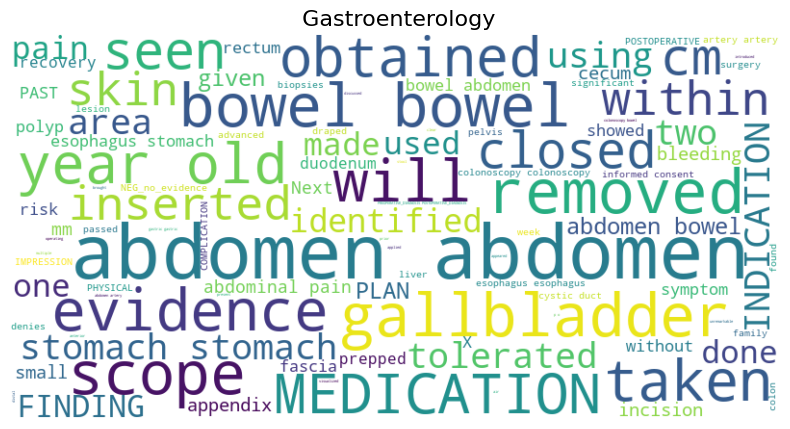

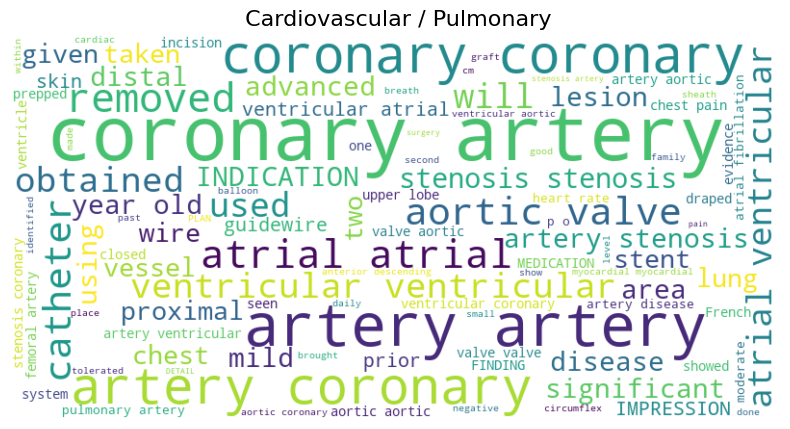

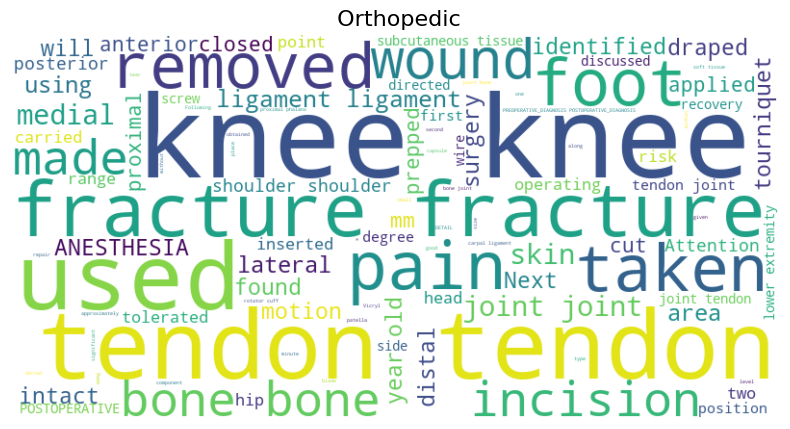

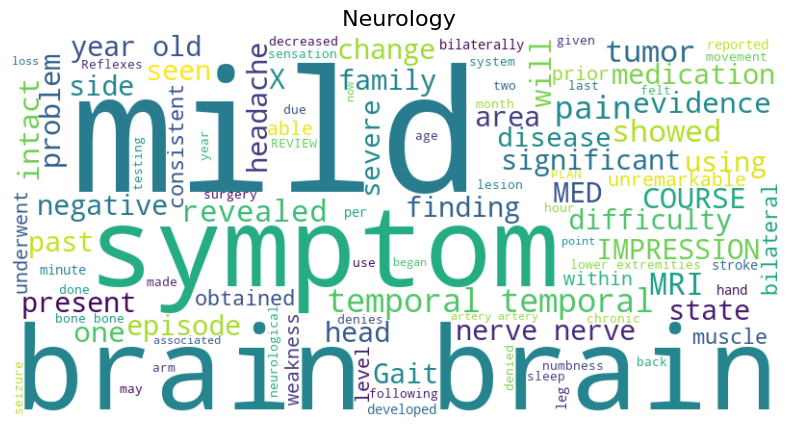

In [19]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS).union({
    'patient', 'hospital', 'procedure', 'history', 'mg', 'discharge',
    'report', 'right', 'left', 'date', 'time', 'evaluation', 'diagnosis',
    'medical', 'noted', 'performed', 'placed', 'day', 'dr', 'well',
    'normal', 'status', 'room', 'exam', 'examination', 'blood', 'pressure'
})

def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, stopwords=custom_stopwords).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

for specialty in target_specialties:
    text = " ".join(data[data["medical_specialty"] == specialty]["combined_text"])
    plot_wordcloud(text, specialty)


Accuracy: 0.95

Classification Report:
                              precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.95      0.91      0.93        44
           Gastroenterology       0.96      1.00      0.98        44
                  Neurology       0.92      0.98      0.95        45
                 Orthopedic       0.98      0.91      0.94        44

                   accuracy                           0.95       177
                  macro avg       0.95      0.95      0.95       177
               weighted avg       0.95      0.95      0.95       177



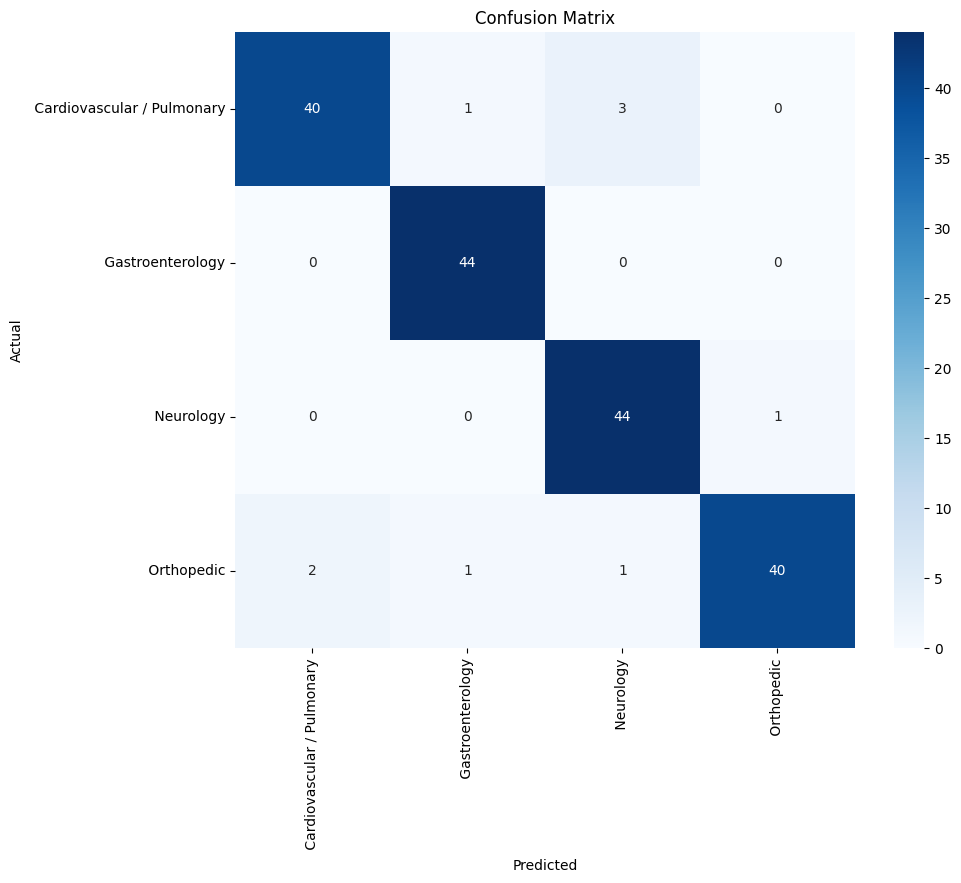

In [20]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Train an Encoder model (Linear SVM acts as an encoding classifier over TF-IDF)
clf = LinearSVC(dual=False, C=1.0, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


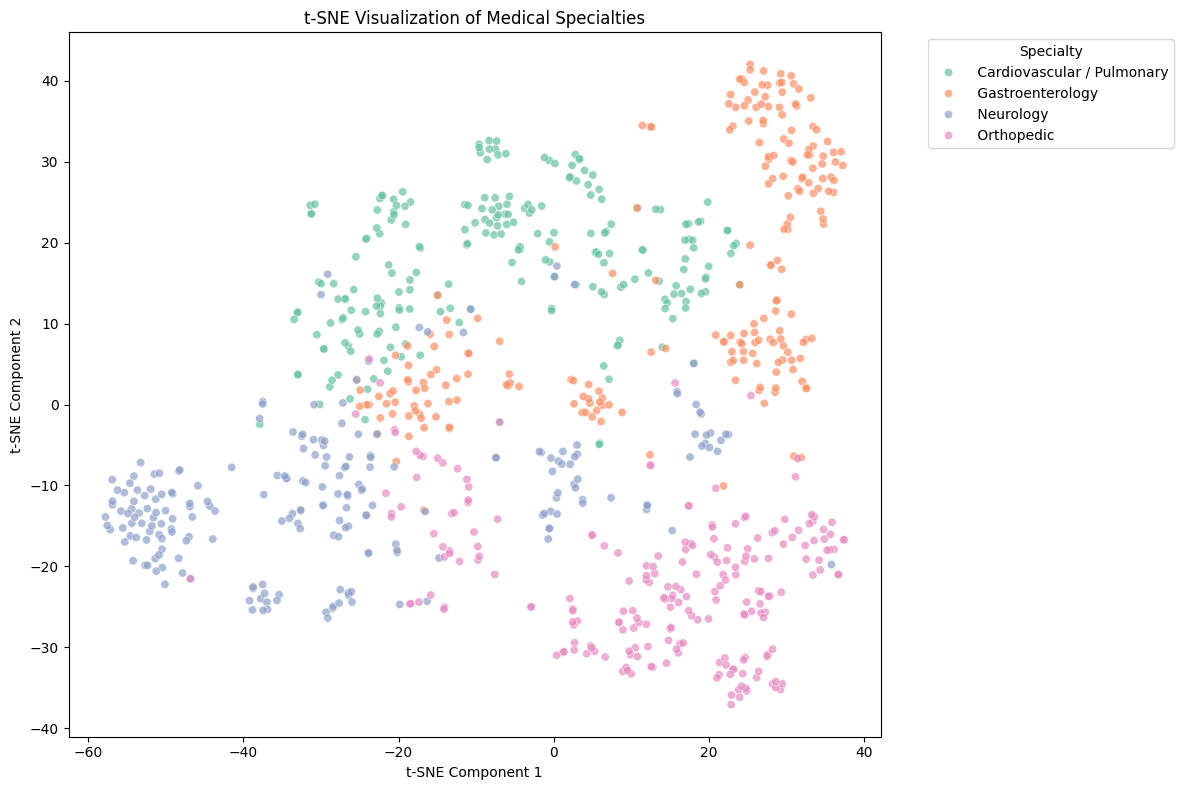

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, random_state=42)
# X is the sparse TF-IDF matrix from earlier cells
X_tsne = tsne.fit_transform(X.toarray())

# Plot the results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=labels, 
    palette='Set2', 
    alpha=0.7
)
plt.title('t-SNE Visualization of Medical Specialties')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Specialty', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [22]:
import numpy as np

print("\nTop predictive words/phrases per class (SVM coefficients):")
feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(clf.classes_):
    if len(clf.classes_) == 2:
        coef = clf.coef_[0] if i == 1 else -clf.coef_[0]
    else:
        coef = clf.coef_[i]
    top_indices = np.argsort(coef)[-40:]
    top_words = [feature_names[j] for j in top_indices]
    print(f"\n{class_label}:\n{', '.join(reversed(top_words))}")



Top predictive words/phrases per class (SVM coefficients):

 Cardiovascular / Pulmonary:
chest, pulmonary, lung, atrial, myocardial, coronary, cardiac, coronary artery, artery, subclavian, lobe, stent, predicted, atrial atrial, pneumonia, mg, bronchoscopy, stress, patent, trachea, effusion, breath, catheter, upper lobe, chest ray, left subclavian, chest pain, lower lobe, heart, ventricular, chest tube, stenosis, capacity, vein, venous, artery coronary, angioplasty, stenosis stenosis, pneumothorax, aortic

 Gastroenterology:
abdomen, bowel, colonoscopy, abdominal, indication, stomach, abdomen abdomen, gallbladder, colon, bowel bowel, liver, esophagus, hernia, biliary, gastric, stool, laparoscopic, rectal, endoscopy, bleeding, polyps, abdominal pain, quadrant, duct, umbilical, appendix, cholecystitis, nausea, diet, choledocholithiasis, cholelithiasis, esophageal, stomach stomach, ulcer, rectum, liquids, colonoscopy colonoscopy, colic, pelvis, barium

 Neurology:
brain, temporal, cerebra

In [23]:
import json
import pandas as pd

# Load full data again to get raw distinct counts for export
raw_data = pd.read_csv("dataset/mtsamples.csv")
raw_data = raw_data.dropna(subset=["transcription", "medical_specialty"])
raw_data = raw_data[raw_data["transcription"].str.strip() != ""]
counts = raw_data['medical_specialty'].value_counts()

valid_specs = [
    " Gastroenterology",
    " Cardiovascular / Pulmonary",
    " Orthopedic",
    " Neurology"
]

with open('output.json', 'w') as f:
    json.dump({'valid_specs': valid_specs, 'counts': counts.head(10).to_dict()}, f)

print("Saved top 10 specialties and valid_specs to output.json")


Saved top 10 specialties and valid_specs to output.json
